In [1]:
import pyxdf
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def load_emotibit_data(data_path):
    """
    Load XDF file from Emotibit with multiple sensor streams
    
    Args:
        data_path (str): Path to XDF file
    
    Returns:
        dict: Processed sensor streams
    """
    # Load XDF file
    streams, fileheader = pyxdf.load_xdf(data_path)
    
    # Dictionary to store processed streams
    processed_streams = {}
    
    for stream in streams:
        stream_name = stream['info']['name'][0]
        stream_type = stream['info']['type'][0]
        
        # Extract key stream information
        data = np.array(stream['time_series'])
        timestamps = np.array(stream['time_stamps'])
        
        # Try to extract channel names
        try:
            channel_names = [chan['label'][0] for chan in stream['info']['desc'][0]['channels'][0]['channel']]
        except:
            # Fallback to generic naming if extraction fails
            channel_names = [f'{stream_name}_channel_{i+1}' for i in range(data.shape[1])]
        
        # Create a comprehensive stream dictionary
        stream_info = {
            'data': data,
            'timestamps': timestamps,
            'channel_names': channel_names,
            'sampling_rate': float(stream['info']['nominal_srate'][0]),
            'stream_type': stream_type
        }
        
        # Store the stream
        processed_streams[stream_name] = stream_info
        
        # Print stream summary
        print(f"\nStream: {stream_name}")
        print(f"Type: {stream_type}")
        print(f"Channels: {channel_names}")
        print(f"Sampling Rate: {stream_info['sampling_rate']} Hz")
        print(f"Number of Samples: {len(timestamps)}")
    
    return processed_streams


def visualize_streams(processed_streams):
    """
    Visualize different sensor streams
    
    Args:
        processed_streams (dict): Processed Emotibit streams
    """
    # Plotting configuration
    sensor_types = {
        'ppg': {'color': 'red', 'title': 'Photoplethysmogram (PPG)'},
        'accel': {'color': 'blue', 'title': 'Accelerometer'},
        'gyro': {'color': 'green', 'title': 'Gyroscope'},
        'temp': {'color': 'orange', 'title': 'Temperature'}
    }
    
    # Create a figure with subplots
    fig, axes = plt.subplots(len(processed_streams), 1, figsize=(12, 3*len(processed_streams)))
    
    # Ensure axes is always a list
    if len(processed_streams) == 1:
        axes = [axes]
    
    # Iterate through streams and plot
    for i, (stream_name, stream_data) in enumerate(processed_streams.items()):
        # Determine plot style based on stream type
        plot_style = next((style for key, style in sensor_types.items() if key in stream_name.lower()), 
                           {'color': 'purple', 'title': stream_name})
        
        # Plot each channel in the stream
        for j in range(stream_data['data'].shape[1]):
            axes[i].plot(stream_data['timestamps'], 
                         stream_data['data'][:, j], 
                         color=plot_style['color'], 
                         label=stream_data['channel_names'][j])
        
        axes[i].set_title(plot_style['title'])
        axes[i].set_xlabel('Time (seconds)')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

def extract_ppg_data(processed_streams):
    """
    Extract and process PPG data specifically
    
    Args:
        processed_streams (dict): Processed Emotibit streams
    
    Returns:
        dict: Processed PPG data or None if not found
    """
    # Find PPG streams (case-insensitive)
    ppg_streams = {name: stream for name, stream in processed_streams.items() 
                   if 'ppg' in name.lower()}
    
    if not ppg_streams:
        print("No PPG streams found!")
        return None
    
    # If multiple PPG streams, choose the first
    ppg_stream_name = list(ppg_streams.keys())[0]
    ppg_data = ppg_streams[ppg_stream_name]
    
    # Basic PPG analysis
    ppg_analysis = {
        'stream_name': ppg_stream_name,
        'channels': ppg_data['channel_names'],
        'sampling_rate': ppg_data['sampling_rate'],
        'total_duration': ppg_data['timestamps'][-1] - ppg_data['timestamps'][0],
        'channel_stats': []
    }
    
    # Compute statistics for each channel
    for i, channel in enumerate(ppg_data['channel_names']):
        channel_data = ppg_data['data'][:, i]
        ppg_analysis['channel_stats'].append({
            'channel': channel,
            'mean': np.mean(channel_data),
            'std': np.std(channel_data),
            'min': np.min(channel_data),
            'max': np.max(channel_data)
        })
    
    return ppg_analysis


Stream: GYRO_X
Type: GyroscopeX
Channels: ['GYRO_X_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: GYRO_Z
Type: GyroscopeZ
Channels: ['GYRO_Z_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: PPG_IR
Type: PPGInfrared
Channels: ['PPG_IR_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: ACC_Y
Type: AccelerometerY
Channels: ['ACC_Y_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: TEMP1
Type: Temperature
Channels: ['TEMP1_channel_1']
Sampling Rate: 7.5 Hz
Number of Samples: 94

Stream: HR
Type: HeartRate
Channels: []
Sampling Rate: 0.0 Hz
Number of Samples: 0

Stream: THERM
Type: Thermopile
Channels: ['THERM_channel_1']
Sampling Rate: 7.5 Hz
Number of Samples: 94

Stream: PPG_RED
Type: PPGRed
Channels: ['PPG_RED_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: PPG_GRN
Type: PPGGreen
Channels: ['PPG_GRN_channel_1']
Sampling Rate: 25.0 Hz
Number of Samples: 314

Stream: ACC_Z
Type: AccelerometerZ
Channe

/var/folders/gz/tx7kktg51gx_mp4b7_h9jh_80000gq/T/ipykernel_29859/1508233302.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


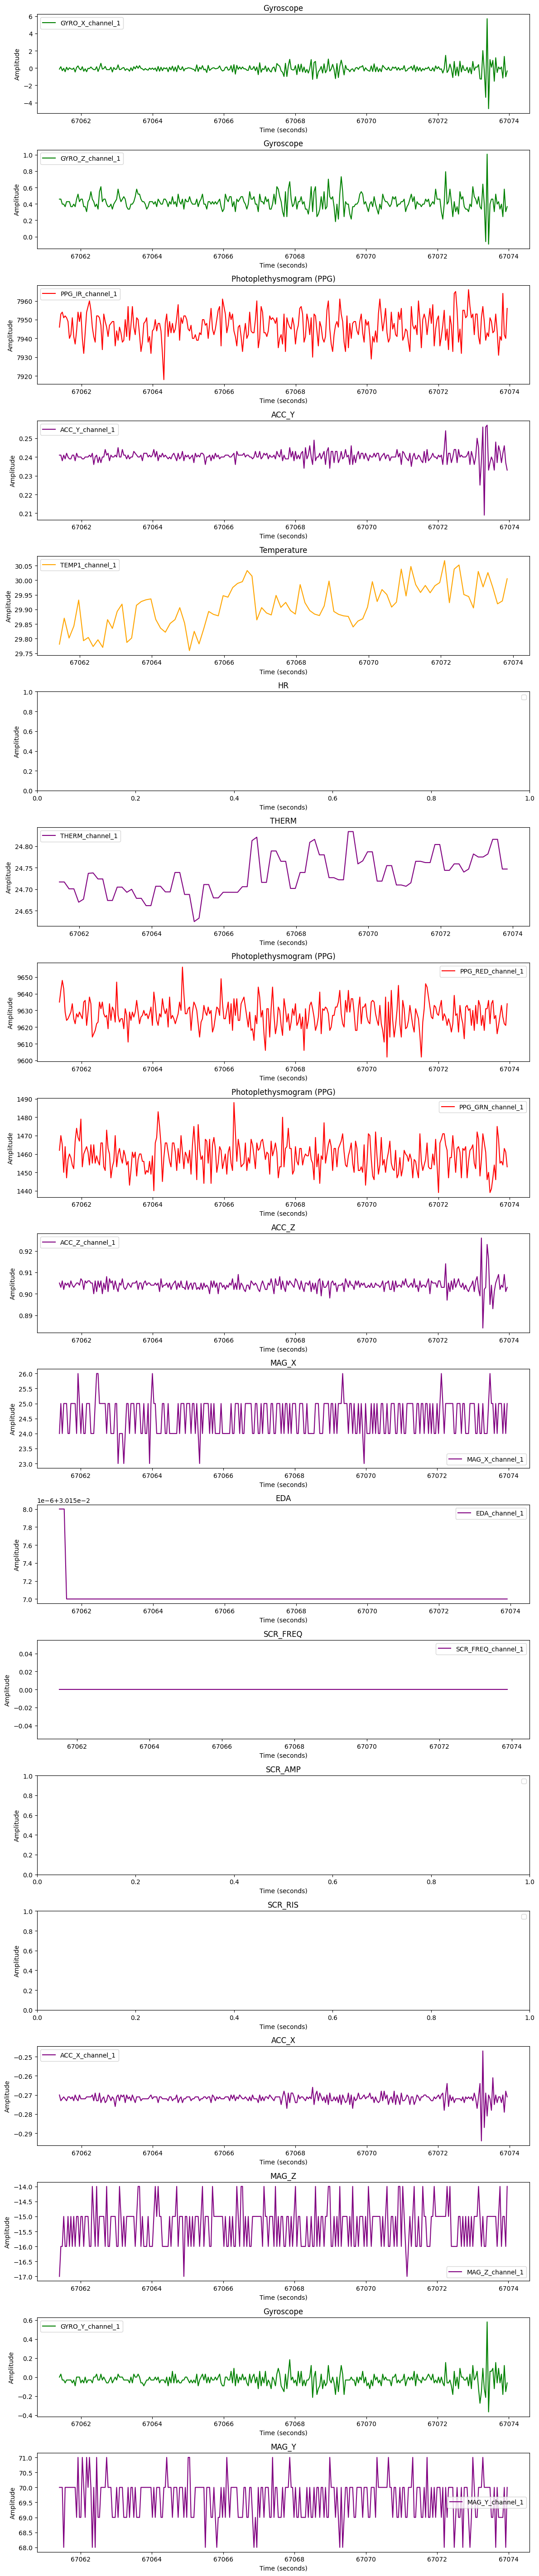


PPG Analysis:
Stream Name: PPG_IR
Sampling Rate: 25.0 Hz
Total Duration: 12.55 seconds

Channel Statistics:

Channel: PPG_IR_channel_1
  Mean: 7946.1880
  Std Dev: 7.2084
  Min: 7918.0000
  Max: 7966.0000


In [4]:
# Main execution
if __name__ == "__main__":
    # Replace with your Emotibit XDF file path
    data_path = '/Users/mli414/Downloads/run1.xdf'
    
    # Load Emotibit streams
    processed_streams = load_emotibit_data(data_path)
    
    # Visualize all streams
    visualize_streams(processed_streams)
    
    # Extract and analyze PPG data
    ppg_analysis = extract_ppg_data(processed_streams)
    if ppg_analysis:
        print("\nPPG Analysis:")
        print(f"Stream Name: {ppg_analysis['stream_name']}")
        print(f"Sampling Rate: {ppg_analysis['sampling_rate']} Hz")
        print(f"Total Duration: {ppg_analysis['total_duration']:.2f} seconds")
        print("\nChannel Statistics:")
        for stats in ppg_analysis['channel_stats']:
            print(f"\nChannel: {stats['channel']}")
            print(f"  Mean: {stats['mean']:.4f}")
            print(f"  Std Dev: {stats['std']:.4f}")
            print(f"  Min: {stats['min']:.4f}")
            print(f"  Max: {stats['max']:.4f}")